In [ ]:
!pip -q install openpyxl scikit-learn

In [ ]:
import os
import copy
import pickle
import zipfile
import shutil
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from google.colab import files

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
# En este experimento NO se fija semilla para el split.
# La intención es que cada corrida tenga un split aleatorio distinto.
# Pero sí se fija la semilla de entrenamiento antes de crear cada modelo.

TRAINING_SEED = 42

def set_training_seed(seed=42):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

OUTPUT_ROOT = "GeoFormer_outputs_20_random_splits_2_heads_fixed_epochs"

if os.path.exists(OUTPUT_ROOT):
    shutil.rmtree(OUTPUT_ROOT)

os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Carpeta raíz de salida limpia:", OUTPUT_ROOT)

Dispositivo: cpu
Carpeta raíz de salida limpia: GeoFormer_outputs_20_random_splits_2_heads_fixed_epochs


In [ ]:
uploaded = files.upload()

excel_path = list(uploaded.keys())[0]
df = pd.read_excel(excel_path)

df.columns = df.columns.str.strip()

ID_COL = "fid"
TARGET_COL = "class"
CAT_COLS = ["UGS", "GMF", "CLC", "SLOPE"]
GROUP_COL = None

excluded_cols = [ID_COL, TARGET_COL] + CAT_COLS
if GROUP_COL is not None:
    excluded_cols.append(GROUP_COL)

NUM_COLS = [c for c in df.columns if c not in excluded_cols]

print("Archivo cargado:", excel_path)
print("Dimensiones:", df.shape)

print("\nVariable ID:")
print(ID_COL)

print("\nVariable objetivo:")
print(TARGET_COL)

print("\nVariables categóricas de la frase geoambiental:")
for col in CAT_COLS:
    print(f"- {col}: str")

print("\nVariables continuas:")
for col in NUM_COLS:
    print(f"- {col}: float64")

display(df.head())
print("\nTipos originales leídos desde el Excel:")
print(df.dtypes)

Saving DataPaul.xlsx to DataPaul (1).xlsx
Archivo cargado: DataPaul (1).xlsx
Dimensiones: (400, 10)

Variable ID:
fid

Variable objetivo:
class

Variables categóricas de la frase geoambiental:
- UGS: str
- GMF: str
- CLC: str
- SLOPE: str

Variables continuas:
- TRI: float64
- TWI: float64
- Curvature: float64
- Elevation: float64


,fid,UGS,GMF,CLC,SLOPE,TRI,TWI,Curvature,Elevation,class
0,1,Srccsb,Sgf,31122.0,6,7.158911,2.103482,0.0128,1554,1
1,2,Rbmca,Dmc,2311.0,5,3.605551,2.897750,0.0256,2164,1
2,3,Srccp,Vla,232.0,5,5.220153,3.082989,-0.0128,2317,1
3,4,Srccp,Vla,32222.0,5,3.535534,3.946606,0.0000,2336,1
4,5,Srccp,Vle,232.0,5,3.535534,2.845010,0.0000,2274,1



Tipos originales leídos desde el Excel:
fid            int64
UGS           object
GMF           object
CLC          float64
SLOPE          int64
TRI          float64
TWI          float64
Curvature    float64
Elevation      int64
class          int64
dtype: object


In [ ]:
ID_COL = "fid"
TARGET_COL = "class"

CAT_COLS = ["UGS", "GMF", "CLC", "SLOPE"]

GROUP_COL = None

excluded_cols = [ID_COL, TARGET_COL] + CAT_COLS
if GROUP_COL is not None:
    excluded_cols.append(GROUP_COL)

NUM_COLS = [c for c in df.columns if c not in excluded_cols]

print("ID:", ID_COL)
print("Target:", TARGET_COL)
print("Categóricas:", CAT_COLS)
print("Continuas:", NUM_COLS)

ID: fid
Target: class
Categóricas: ['UGS', 'GMF', 'CLC', 'SLOPE']
Continuas: ['TRI', 'TWI', 'Curvature', 'Elevation']


In [ ]:
df = df.copy()

df = df.dropna(subset=[TARGET_COL]).reset_index(drop=True)
df[TARGET_COL] = df[TARGET_COL].astype(int)

def clean_category_value(v):
    if pd.isna(v):
        return "__MISSING__"
    if isinstance(v, float) and v.is_integer():
        return str(int(v))
    return str(v).strip()

for col in CAT_COLS:
    df[col] = df[col].apply(clean_category_value).astype(str)

for col in NUM_COLS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Distribución de la variable objetivo:")
print(df[TARGET_COL].value_counts())
print(df[TARGET_COL].value_counts(normalize=True))

Distribución de la variable objetivo:
class
1    269
0    131
Name: count, dtype: int64
class
1    0.6725
0    0.3275
Name: proportion, dtype: float64


In [ ]:
class GeoFormerDataset(Dataset):
    def __init__(self, X_cat, X_num, y):
        self.X_cat = torch.tensor(X_cat, dtype=torch.long)
        self.X_num = torch.tensor(X_num, dtype=torch.float64)
        self.y = torch.tensor(y, dtype=torch.float64)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_cat[idx], self.X_num[idx], self.y[idx]

In [ ]:
class GeoFormerAttentionBlock(nn.Module):
    def __init__(
        self,
        d_model,
        n_heads,
        ff_dim,
        dropout
    ):
        super().__init__()

        self.self_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout_attn = nn.Dropout(dropout)
        self.dropout_ffn = nn.Dropout(dropout)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model)
        )

    def forward(self, x, return_attention=False):
        x_norm = self.norm1(x)

        attn_out, attn_weights = self.self_attn(
            x_norm,
            x_norm,
            x_norm,
            need_weights=return_attention,
            average_attn_weights=False
        )

        x = x + self.dropout_attn(attn_out)

        x_norm = self.norm2(x)
        x = x + self.dropout_ffn(self.ffn(x_norm))

        if return_attention:
            return x, attn_weights

        return x, None


class GeoFormer(nn.Module):
    def __init__(
        self,
        vocab_sizes,
        num_numeric,
        d_model=16,
        n_heads=2,
        n_layers=1,
        ff_dim=48,
        num_proj_dim=8,
        mlp_hidden=24,
        dropout=0.35,
        pooling="mean"
    ):
        super().__init__()

        assert d_model % n_heads == 0, "d_model debe ser divisible entre n_heads"
        assert pooling in ["mean", "cls"], "pooling debe ser 'mean' o 'cls'"

        self.vocab_sizes = vocab_sizes
        self.num_categorical = len(vocab_sizes)
        self.num_numeric = num_numeric
        self.d_model = d_model
        self.pooling = pooling

        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_size, d_model)
            for vocab_size in vocab_sizes
        ])

        self.factor_embedding = nn.Embedding(self.num_categorical, d_model)

        self.cat_input_norm = nn.LayerNorm(d_model)
        self.cat_dropout = nn.Dropout(dropout)

        if pooling == "cls":
            self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        else:
            self.cls_token = None

        self.transformer_encoder = nn.ModuleList([
            GeoFormerAttentionBlock(
                d_model=d_model,
                n_heads=n_heads,
                ff_dim=ff_dim,
                dropout=dropout
            )
            for _ in range(n_layers)
        ])

        self.cat_output_norm = nn.LayerNorm(d_model)

        if num_numeric > 0:
            self.numeric_branch = nn.Sequential(
                nn.Linear(num_numeric, num_proj_dim),
                nn.LayerNorm(num_proj_dim),
                nn.GELU(),
                nn.Dropout(dropout)
            )
            fusion_dim = d_model + num_proj_dim
        else:
            self.numeric_branch = None
            fusion_dim = d_model

        self.prediction_head = nn.Sequential(
            nn.LayerNorm(fusion_dim),
            nn.Linear(fusion_dim, mlp_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, max(mlp_hidden // 2, 4)),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(max(mlp_hidden // 2, 4), 1)
        )

        self._reset_parameters()

    def _reset_parameters(self):
        for emb in self.embeddings:
            nn.init.normal_(emb.weight, mean=0.0, std=0.02)

        nn.init.normal_(self.factor_embedding.weight, mean=0.0, std=0.02)

        if self.cls_token is not None:
            nn.init.normal_(self.cls_token, mean=0.0, std=0.02)

        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x_cat, x_num, return_attention=False):
        batch_size = x_cat.size(0)

        token_list = []
        for j, emb in enumerate(self.embeddings):
            token_j = emb(x_cat[:, j])
            token_list.append(token_j)

        z = torch.stack(token_list, dim=1)

        factor_ids = torch.arange(
            self.num_categorical,
            device=x_cat.device
        ).unsqueeze(0).expand(batch_size, -1)

        z = z + self.factor_embedding(factor_ids)
        z = self.cat_input_norm(z)
        z = self.cat_dropout(z)

        if self.pooling == "cls":
            cls = self.cls_token.expand(batch_size, -1, -1)
            z = torch.cat([cls, z], dim=1)

        attention_layers = []

        for encoder_block in self.transformer_encoder:
            z, attn_weights = encoder_block(
                z,
                return_attention=return_attention
            )

            if return_attention:
                attention_layers.append(attn_weights)

        z = self.cat_output_norm(z)

        if self.pooling == "mean":
            h_cat = z.mean(dim=1)
        else:
            h_cat = z[:, 0, :]

        if self.numeric_branch is not None:
            h_num = self.numeric_branch(x_num)
            h = torch.cat([h_cat, h_num], dim=1)
        else:
            h = h_cat

        logits = self.prediction_head(h).squeeze(1)

        if return_attention:
            attention = torch.stack(attention_layers, dim=0)
            return logits, attention

        return logits

In [ ]:

HYPERPARAMS = {
    "d_model": 16,
    "n_heads": 2,
    "n_layers": 1,
    "ff_dim": 56,
    "num_proj_dim": 12,
    "mlp_hidden": 28,
    "dropout": 0.34,
    "pooling": "mean",

    "lr": 2.5e-4,
    "weight_decay": 5e-3,

    # Todas las corridas entrenan el mismo número de épocas.
    "epochs": 50,

    "batch_size": 32,
    "max_grad_norm": 1.5,

    "threshold_metric": "min_errors"
}

N_RUNS = 20
VALIDATION_SIZE = 0.25

HYPERPARAMS

{'d_model': 16,
 'n_heads': 2,
 'n_layers': 1,
 'ff_dim': 56,
 'num_proj_dim': 12,
 'mlp_hidden': 28,
 'dropout': 0.34,
 'pooling': 'mean',
 'lr': 0.00025,
 'weight_decay': 0.005,
 'epochs': 50,
 'batch_size': 32,
 'max_grad_norm': 1.5,
 'threshold_metric': 'min_errors'}

In [ ]:

def save_current_figure(output_path_png, dpi=300):
    """
    Guarda la figura actual en PNG y SVG.
    """
    output_path_png = str(output_path_png)
    output_path_svg = output_path_png.replace(".png", ".svg")

    plt.savefig(
        output_path_png,
        dpi=dpi,
        bbox_inches="tight"
    )

    plt.savefig(
        output_path_svg,
        format="svg",
        bbox_inches="tight"
    )

    return output_path_png, output_path_svg


def create_random_split():
    """
    Crea un split 75/25 sin semilla fija.

    Si GROUP_COL existe, usa GroupShuffleSplit sin random_state.
    Si no, usa train_test_split estratificado sin random_state.
    """
    indices = np.arange(len(df))
    y_all = df[TARGET_COL].values

    if GROUP_COL is not None and GROUP_COL in df.columns:
        print("Usando separación por grupos espaciales sin semilla fija:", GROUP_COL)

        groups = df[GROUP_COL].values

        gss_val = GroupShuffleSplit(
            n_splits=1,
            test_size=VALIDATION_SIZE,
            random_state=None
        )

        train_idx, val_idx = next(
            gss_val.split(df, y_all, groups=groups)
        )

    else:
        train_idx, val_idx = train_test_split(
            indices,
            test_size=VALIDATION_SIZE,
            random_state=None,
            stratify=y_all
        )

    return train_idx, val_idx


def build_preprocessing_for_split(train_idx):
    """
    Ajusta vocabularios categóricos, imputador y escalador usando solo train.
    """
    cat_maps = {}

    for col in CAT_COLS:
        train_values = sorted(df.iloc[train_idx][col].unique())

        mapping = {"__UNK__": 0}

        for i, value in enumerate(train_values, start=1):
            mapping[value] = i

        cat_maps[col] = mapping

    vocab_sizes = [len(cat_maps[col]) for col in CAT_COLS]

    def encode_categorical(frame):
        arr = np.zeros((len(frame), len(CAT_COLS)), dtype=np.int64)

        for j, col in enumerate(CAT_COLS):
            mapping = cat_maps[col]
            arr[:, j] = frame[col].apply(lambda v: mapping.get(v, 0)).values

        return arr

    if len(NUM_COLS) > 0:
        imputer = SimpleImputer(strategy="median")
        scaler = StandardScaler()

        X_num_train_raw = df.iloc[train_idx][NUM_COLS]
        X_num_train_imp = imputer.fit_transform(X_num_train_raw)
        scaler.fit(X_num_train_imp)

        def transform_numeric(frame):
            x_imp = imputer.transform(frame[NUM_COLS])
            x_scaled = scaler.transform(x_imp)
            return x_scaled.astype(np.float64)

    else:
        imputer = None
        scaler = None

        def transform_numeric(frame):
            return np.zeros((len(frame), 0), dtype=np.float64)

    return cat_maps, vocab_sizes, encode_categorical, imputer, scaler, transform_numeric


def prepare_data_for_split(train_idx, val_idx):
    cat_maps, vocab_sizes, encode_categorical, imputer, scaler, transform_numeric = (
        build_preprocessing_for_split(train_idx)
    )

    X_cat = encode_categorical(df)
    X_num = transform_numeric(df)
    y = df[TARGET_COL].values.astype(np.float64)

    X_cat_train = X_cat[train_idx]
    X_num_train = X_num[train_idx]
    y_train = y[train_idx]

    X_cat_val = X_cat[val_idx]
    X_num_val = X_num[val_idx]
    y_val = y[val_idx]

    return {
        "cat_maps": cat_maps,
        "vocab_sizes": vocab_sizes,
        "imputer": imputer,
        "scaler": scaler,
        "X_cat": X_cat,
        "X_num": X_num,
        "y": y,
        "X_cat_train": X_cat_train,
        "X_num_train": X_num_train,
        "y_train": y_train,
        "X_cat_val": X_cat_val,
        "X_num_val": X_num_val,
        "y_val": y_val
    }


def make_loaders(split_data):
    train_ds = GeoFormerDataset(
        split_data["X_cat_train"],
        split_data["X_num_train"],
        split_data["y_train"]
    )

    val_ds = GeoFormerDataset(
        split_data["X_cat_val"],
        split_data["X_num_val"],
        split_data["y_val"]
    )

    generator = torch.Generator()
    generator.manual_seed(TRAINING_SEED)

    train_loader = DataLoader(
        train_ds,
        batch_size=HYPERPARAMS["batch_size"],
        shuffle=True,
        drop_last=False,
        generator=generator
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=HYPERPARAMS["batch_size"],
        shuffle=False
    )

    return train_loader, val_loader

In [ ]:

def evaluate_loader(model, loader, criterion):
    model.eval()

    all_y = []
    all_probs = []
    losses = []

    with torch.no_grad():
        for x_cat_batch, x_num_batch, y_batch in loader:
            x_cat_batch = x_cat_batch.to(device)
            x_num_batch = x_num_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(x_cat_batch, x_num_batch)
            loss = criterion(logits, y_batch)

            probs = torch.sigmoid(logits)

            losses.append(loss.item() * len(y_batch))
            all_y.append(y_batch.detach().cpu().numpy())
            all_probs.append(probs.detach().cpu().numpy())

    all_y = np.concatenate(all_y)
    all_probs = np.concatenate(all_probs)

    mean_loss = np.sum(losses) / len(all_y)

    return mean_loss, all_y, all_probs


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()

    losses = []

    for x_cat_batch, x_num_batch, y_batch in loader:
        x_cat_batch = x_cat_batch.to(device)
        x_num_batch = x_num_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(x_cat_batch, x_num_batch)
        loss = criterion(logits, y_batch)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=HYPERPARAMS["max_grad_norm"]
        )

        optimizer.step()

        losses.append(loss.item() * len(y_batch))

    return np.sum(losses) / len(loader.dataset)


def safe_auc(y_true, y_prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_prob)


def safe_average_precision(y_true, y_prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return average_precision_score(y_true, y_prob)


def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "AUC": safe_auc(y_true, y_prob),
        "AUPRC": safe_average_precision(y_true, y_prob),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Brier": brier_score_loss(y_true, y_prob)
    }


def find_best_threshold(y_true, y_prob, metric="min_errors"):
    thresholds = np.linspace(0.01, 0.99, 99)

    best_threshold = 0.5
    best_score = -np.inf

    report = []

    for th in thresholds:
        y_pred = (y_prob >= th).astype(int)

        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        total_errors = fp + fn

        if metric == "f1":
            score = f1_score(y_true, y_pred, zero_division=0)

        elif metric == "accuracy":
            score = accuracy_score(y_true, y_pred)

        elif metric == "balanced_accuracy":
            score = balanced_accuracy_score(y_true, y_pred)

        elif metric == "youden":
            sensitivity = tp / (tp + fn + 1e-12)
            specificity = tn / (tn + fp + 1e-12)
            score = sensitivity + specificity - 1

        elif metric == "min_errors":
            score = -total_errors + 1e-3 * balanced_accuracy_score(y_true, y_pred)

        else:
            raise ValueError("metric debe ser: f1, accuracy, balanced_accuracy, youden o min_errors")

        report.append({
            "threshold": th,
            "metric": metric,
            "score": score,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
            "total_errors": total_errors
        })

        if score > best_score:
            best_score = score
            best_threshold = th

    return best_threshold, best_score, pd.DataFrame(report)


def summarize_thresholds(y_true, y_prob):
    rows = []

    for metric in ["f1", "accuracy", "balanced_accuracy", "youden", "min_errors"]:
        th, score, _ = find_best_threshold(y_true, y_prob, metric=metric)
        y_pred = (y_prob >= th).astype(int)

        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        rows.append({
            "metric": metric,
            "threshold": th,
            "score": score,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
            "total_errors": fp + fn
        })

    return pd.DataFrame(rows)


def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [ ]:

def run_one_random_split(run_id):
    run_name = f"run_{run_id:02d}"
    print("=" * 80)
    print(f"Ejecutando {run_name} / {N_RUNS}")
    print("=" * 80)

    run_dir = os.path.join(OUTPUT_ROOT, run_name)
    os.makedirs(run_dir, exist_ok=True)

    train_idx, val_idx = create_random_split()

    split_data = prepare_data_for_split(train_idx, val_idx)

    # Se fija la semilla de entrenamiento después de crear el split.
    # Así el split cambia, pero la inicialización del modelo y el shuffle
    # del DataLoader quedan controlados entre corridas.
    set_training_seed(TRAINING_SEED)

    train_loader, val_loader = make_loaders(split_data)

    model = GeoFormer(
        vocab_sizes=split_data["vocab_sizes"],
        num_numeric=split_data["X_num_train"].shape[1],
        d_model=HYPERPARAMS["d_model"],
        n_heads=HYPERPARAMS["n_heads"],
        n_layers=HYPERPARAMS["n_layers"],
        ff_dim=HYPERPARAMS["ff_dim"],
        num_proj_dim=HYPERPARAMS["num_proj_dim"],
        mlp_hidden=HYPERPARAMS["mlp_hidden"],
        dropout=HYPERPARAMS["dropout"],
        pooling=HYPERPARAMS["pooling"]
    ).to(device).double()

    n_params = count_trainable_parameters(model)

    y_train = split_data["y_train"]
    n_pos = np.sum(y_train == 1)
    n_neg = np.sum(y_train == 0)
    pos_weight_value = n_neg / max(n_pos, 1)

    pos_weight = torch.tensor(
        [pos_weight_value],
        dtype=torch.float64,
        device=device
    )

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=HYPERPARAMS["lr"],
        weight_decay=HYPERPARAMS["weight_decay"]
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )

    best_val_loss = np.inf
    best_epoch = 0

    history = []

    start_time = time.time()

    for epoch in range(1, HYPERPARAMS["epochs"] + 1):
        train_loss = train_one_epoch(
            model=model,
            loader=train_loader,
            criterion=criterion,
            optimizer=optimizer
        )

        val_loss, val_y_eval, val_probs = evaluate_loader(
            model=model,
            loader=val_loader,
            criterion=criterion
        )

        val_auc = safe_auc(val_y_eval, val_probs)
        current_lr = optimizer.param_groups[0]["lr"]

        history.append({
            "run": run_id,
            "run_name": run_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_auc": val_auc,
            "lr": current_lr
        })

        # No se usa para detener ni para restaurar el modelo.
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch

        if epoch == 1 or epoch % 10 == 0:
            print(
                f"{run_name} | epoch {epoch:03d} | "
                f"train_loss={train_loss:.4f} | "
                f"val_loss={val_loss:.4f} | "
                f"val_auc={val_auc:.4f}"
            )

    train_time_seconds = time.time() - start_time

    # La evaluación se hace con el modelo final después de entrenar todas las épocas.
    final_epoch = HYPERPARAMS["epochs"]

    history_df = pd.DataFrame(history)
    history_df.to_csv(
        os.path.join(run_dir, f"{run_name}_training_history.csv"),
        index=False
    )

    plt.figure(figsize=(7, 4))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.title(f"Curva de pérdida - {run_name}")
    save_current_figure(
        os.path.join(run_dir, f"{run_name}_loss_curve.png"),
        dpi=300
    )
    plt.show()

    train_loss, train_y_eval, train_probs = evaluate_loader(
        model,
        train_loader,
        criterion
    )

    val_loss, val_y_eval, val_probs = evaluate_loader(
        model,
        val_loader,
        criterion
    )

    best_threshold, best_val_score, threshold_report_df = find_best_threshold(
        val_y_eval,
        val_probs,
        metric=HYPERPARAMS["threshold_metric"]
    )

    threshold_summary_df = summarize_thresholds(val_y_eval, val_probs)
    threshold_summary_df["run"] = run_id
    threshold_summary_df["run_name"] = run_name

    train_metrics = compute_metrics(
        train_y_eval,
        train_probs,
        threshold=best_threshold
    )

    val_metrics = compute_metrics(
        val_y_eval,
        val_probs,
        threshold=best_threshold
    )

    val_pred = (val_probs >= best_threshold).astype(int)
    cm = confusion_matrix(val_y_eval, val_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No landslide", "Landslide"]
    )
    disp.plot()
    plt.title(
        f"Matriz de confusión - {run_name}\\n"
        f"threshold={best_threshold:.2f}"
    )
    save_current_figure(
        os.path.join(run_dir, f"{run_name}_confusion_matrix_validation.png"),
        dpi=300
    )
    plt.show()

    # Guardar índices del split para revisar qué puntos cayeron en train/validation
    split_df = pd.DataFrame({
        ID_COL: df[ID_COL].values,
        TARGET_COL: df[TARGET_COL].values,
        "split": "unused"
    })

    split_df.loc[train_idx, "split"] = "train"
    split_df.loc[val_idx, "split"] = "validation"
    split_df["run"] = run_id
    split_df["run_name"] = run_name

    split_df.to_excel(
        os.path.join(run_dir, f"{run_name}_split_indices.xlsx"),
        index=False
    )

    class_distribution_df = (
        split_df
        .groupby(["run", "run_name", "split", TARGET_COL])
        .size()
        .reset_index(name="n")
    )

    class_distribution_df.to_excel(
        os.path.join(run_dir, f"{run_name}_class_distribution.xlsx"),
        index=False
    )

    threshold_report_df["run"] = run_id
    threshold_report_df["run_name"] = run_name

    threshold_report_df.to_excel(
        os.path.join(run_dir, f"{run_name}_threshold_report.xlsx"),
        index=False
    )

    threshold_summary_df.to_excel(
        os.path.join(run_dir, f"{run_name}_threshold_summary.xlsx"),
        index=False
    )

    val_output_df = df.iloc[val_idx][[ID_COL, TARGET_COL] + CAT_COLS].copy()
    val_output_df["run"] = run_id
    val_output_df["run_name"] = run_name
    val_output_df["prob_susceptibilidad"] = val_probs
    val_output_df["pred_class"] = val_pred

    val_output_df.to_excel(
        os.path.join(run_dir, f"{run_name}_validation_predictions.xlsx"),
        index=False
    )

    metrics_rows = []

    for split_name, metrics_dict, loss_value in [
        ("Train", train_metrics, train_loss),
        ("Validation", val_metrics, val_loss)
    ]:
        row = {
            "run": run_id,
            "run_name": run_name,
            "n_heads": HYPERPARAMS["n_heads"],
            "split": split_name,
            "loss": loss_value,
            "best_threshold": best_threshold,
            "best_epoch_by_val_loss": best_epoch,
            "best_val_loss_observed": best_val_loss,
            "final_epoch_used": final_epoch,
            "train_time_seconds": train_time_seconds,
            "n_trainable_parameters": n_params,
            "train_size": len(train_idx),
            "validation_size": len(val_idx),
            "train_class_0": int(np.sum(split_data["y_train"] == 0)),
            "train_class_1": int(np.sum(split_data["y_train"] == 1)),
            "val_class_0": int(np.sum(split_data["y_val"] == 0)),
            "val_class_1": int(np.sum(split_data["y_val"] == 1)),
            "TN": tn if split_name == "Validation" else np.nan,
            "FP": fp if split_name == "Validation" else np.nan,
            "FN": fn if split_name == "Validation" else np.nan,
            "TP": tp if split_name == "Validation" else np.nan,
            "validation_errors": (fp + fn) if split_name == "Validation" else np.nan
        }

        row.update(metrics_dict)
        metrics_rows.append(row)

    metrics_df = pd.DataFrame(metrics_rows)

    metrics_df.to_excel(
        os.path.join(run_dir, f"{run_name}_metrics.xlsx"),
        index=False
    )

    # Guardar modelo opcionalmente por corrida
    model_package = {
        "model_state_dict": model.state_dict(),
        "vocab_sizes": split_data["vocab_sizes"],
        "cat_cols": CAT_COLS,
        "num_cols": NUM_COLS,
        "id_col": ID_COL,
        "target_col": TARGET_COL,
        "hyperparams": HYPERPARAMS,
        "run": run_id,
        "run_name": run_name,
        "best_threshold": best_threshold,
        "best_epoch_by_val_loss": best_epoch,
        "best_val_loss_observed": best_val_loss,
        "final_epoch_used": final_epoch,
        "n_trainable_parameters": n_params
    }

    torch.save(
        model_package,
        os.path.join(run_dir, f"{run_name}_GeoFormer_model.pt")
    )

    preprocessing_package = {
        "cat_maps": split_data["cat_maps"],
        "imputer": split_data["imputer"],
        "scaler": split_data["scaler"],
        "cat_cols": CAT_COLS,
        "num_cols": NUM_COLS
    }

    with open(os.path.join(run_dir, f"{run_name}_preprocessing.pkl"), "wb") as f:
        pickle.dump(preprocessing_package, f)

    print(f"{run_name} finalizado")
    print("Final epoch used:", final_epoch)
    print("Best val-loss epoch observed:", best_epoch)
    print("Best threshold:", best_threshold)
    print("Validation errors:", fp + fn)

    return {
        "run": run_id,
        "run_name": run_name,
        "metrics_df": metrics_df,
        "history_df": history_df,
        "threshold_summary_df": threshold_summary_df,
        "threshold_report_df": threshold_report_df,
        "class_distribution_df": class_distribution_df,
        "split_df": split_df,
        "best_threshold": best_threshold,
        "best_epoch_by_val_loss": best_epoch,
        "best_val_loss_observed": best_val_loss,
        "final_epoch_used": final_epoch,
        "train_time_seconds": train_time_seconds
    }

Ejecutando run_01 / 20
run_01 | epoch 001 | train_loss=0.4738 | val_loss=0.3923 | val_auc=0.8055
run_01 | epoch 010 | train_loss=0.3294 | val_loss=0.2265 | val_auc=0.9738
run_01 | epoch 020 | train_loss=0.2752 | val_loss=0.1427 | val_auc=0.9824
run_01 | epoch 030 | train_loss=0.1972 | val_loss=0.1129 | val_auc=0.9851
run_01 | epoch 040 | train_loss=0.2069 | val_loss=0.1025 | val_auc=0.9873
run_01 | epoch 050 | train_loss=0.1644 | val_loss=0.0929 | val_auc=0.9891


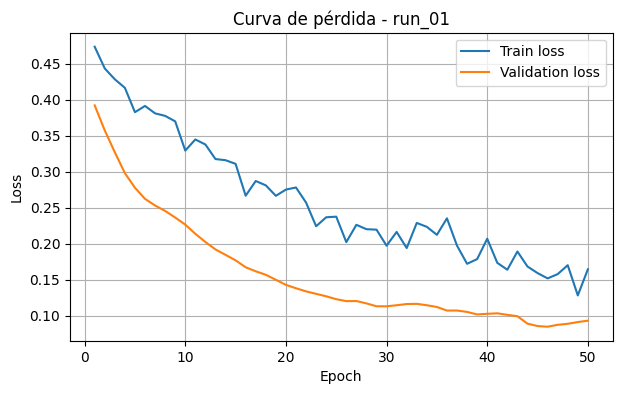

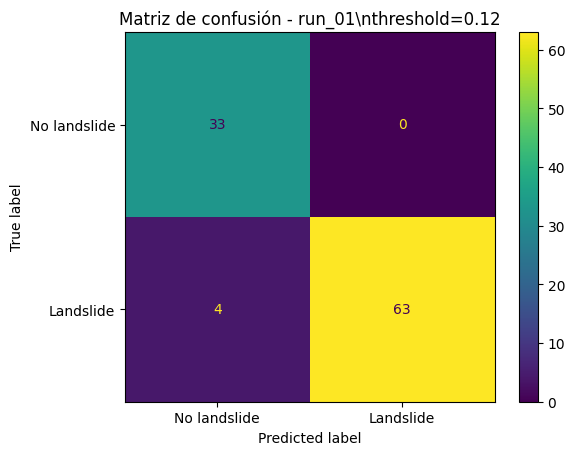

run_01 finalizado
Final epoch used: 50
Best val-loss epoch observed: 46
Best threshold: 0.12
Validation errors: 4
Ejecutando run_02 / 20
run_02 | epoch 001 | train_loss=0.5310 | val_loss=0.4747 | val_auc=0.3573
run_02 | epoch 010 | train_loss=0.3810 | val_loss=0.2989 | val_auc=0.9738
run_02 | epoch 020 | train_loss=0.2628 | val_loss=0.1251 | val_auc=0.9964
run_02 | epoch 030 | train_loss=0.1934 | val_loss=0.0896 | val_auc=0.9968
run_02 | epoch 040 | train_loss=0.1617 | val_loss=0.0766 | val_auc=0.9973
run_02 | epoch 050 | train_loss=0.1334 | val_loss=0.0744 | val_auc=0.9973


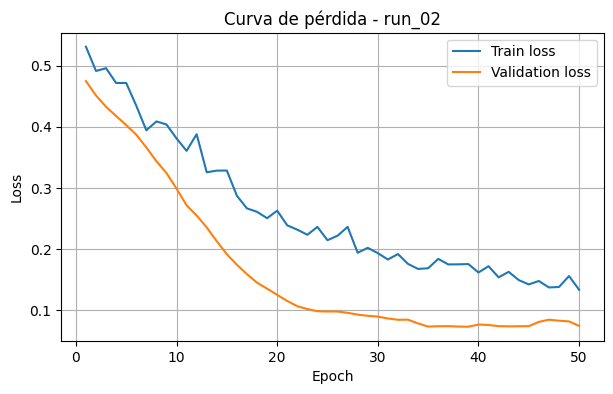

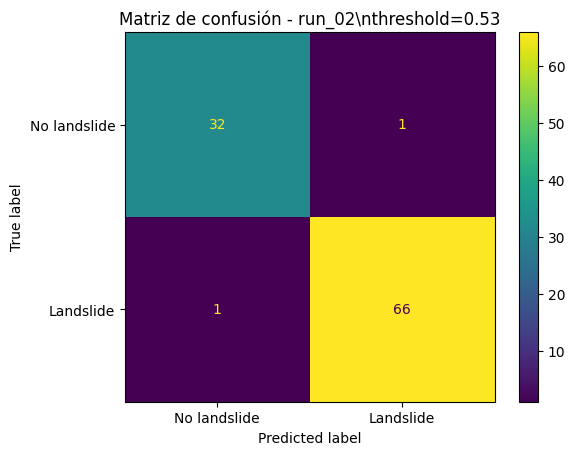

run_02 finalizado
Final epoch used: 50
Best val-loss epoch observed: 39
Best threshold: 0.53
Validation errors: 2
Ejecutando run_03 / 20
run_03 | epoch 001 | train_loss=0.4556 | val_loss=0.4407 | val_auc=0.6160
run_03 | epoch 010 | train_loss=0.3212 | val_loss=0.2706 | val_auc=0.9267
run_03 | epoch 020 | train_loss=0.2782 | val_loss=0.1749 | val_auc=0.9561
run_03 | epoch 030 | train_loss=0.1905 | val_loss=0.1743 | val_auc=0.9570
run_03 | epoch 040 | train_loss=0.1502 | val_loss=0.1864 | val_auc=0.9634
run_03 | epoch 050 | train_loss=0.1629 | val_loss=0.2103 | val_auc=0.9665


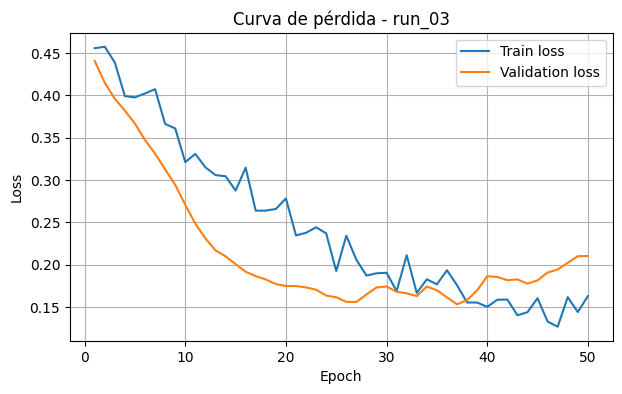

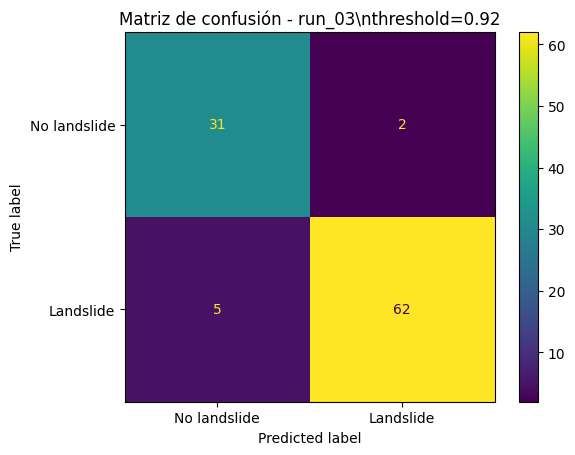

run_03 finalizado
Final epoch used: 50
Best val-loss epoch observed: 37
Best threshold: 0.92
Validation errors: 7
Ejecutando run_04 / 20
run_04 | epoch 001 | train_loss=0.4761 | val_loss=0.4614 | val_auc=0.5269
run_04 | epoch 010 | train_loss=0.3792 | val_loss=0.3301 | val_auc=0.8675
run_04 | epoch 020 | train_loss=0.2640 | val_loss=0.2091 | val_auc=0.9552
run_04 | epoch 030 | train_loss=0.1830 | val_loss=0.1763 | val_auc=0.9742
run_04 | epoch 040 | train_loss=0.1719 | val_loss=0.1533 | val_auc=0.9778
run_04 | epoch 050 | train_loss=0.1214 | val_loss=0.1819 | val_auc=0.9778


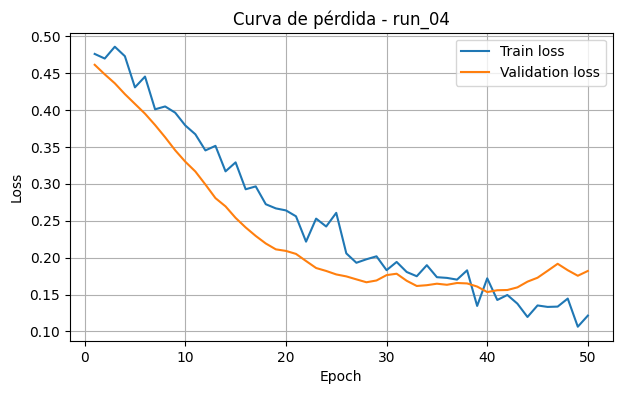

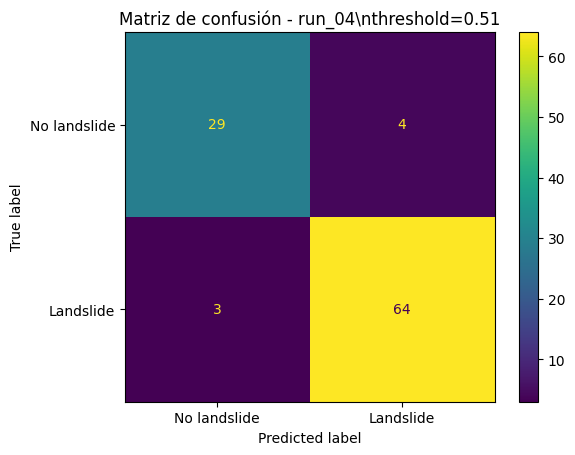

run_04 finalizado
Final epoch used: 50
Best val-loss epoch observed: 40
Best threshold: 0.51
Validation errors: 7
Ejecutando run_05 / 20
run_05 | epoch 001 | train_loss=0.5739 | val_loss=0.4964 | val_auc=0.4396
run_05 | epoch 010 | train_loss=0.3297 | val_loss=0.2522 | val_auc=0.9634
run_05 | epoch 020 | train_loss=0.2103 | val_loss=0.1562 | val_auc=0.9801
run_05 | epoch 030 | train_loss=0.1777 | val_loss=0.1308 | val_auc=0.9833
run_05 | epoch 040 | train_loss=0.1520 | val_loss=0.1081 | val_auc=0.9792
run_05 | epoch 050 | train_loss=0.1183 | val_loss=0.1072 | val_auc=0.9824


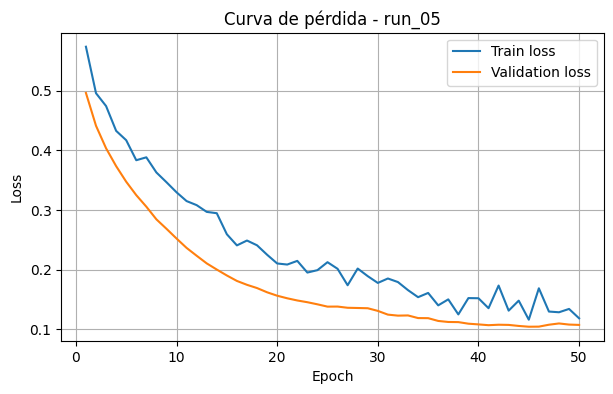

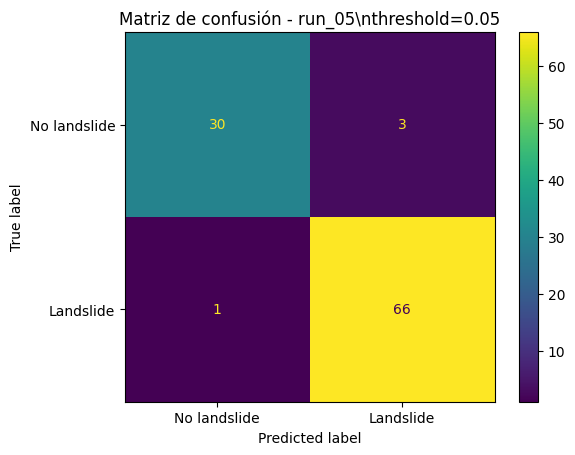

run_05 finalizado
Final epoch used: 50
Best val-loss epoch observed: 45
Best threshold: 0.05
Validation errors: 4
Ejecutando run_06 / 20
run_06 | epoch 001 | train_loss=0.4613 | val_loss=0.4399 | val_auc=0.6495
run_06 | epoch 010 | train_loss=0.3608 | val_loss=0.2903 | val_auc=0.8933
run_06 | epoch 020 | train_loss=0.2771 | val_loss=0.2094 | val_auc=0.9593
run_06 | epoch 030 | train_loss=0.2081 | val_loss=0.1896 | val_auc=0.9665
run_06 | epoch 040 | train_loss=0.1402 | val_loss=0.1740 | val_auc=0.9729
run_06 | epoch 050 | train_loss=0.1755 | val_loss=0.1875 | val_auc=0.9765


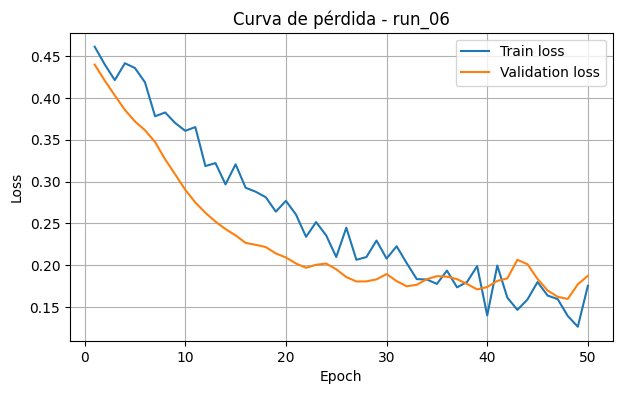

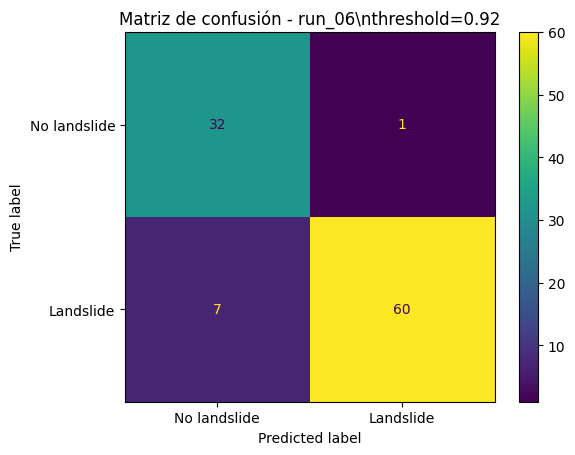

run_06 finalizado
Final epoch used: 50
Best val-loss epoch observed: 48
Best threshold: 0.92
Validation errors: 8
Ejecutando run_07 / 20
run_07 | epoch 001 | train_loss=0.4737 | val_loss=0.4576 | val_auc=0.5482
run_07 | epoch 010 | train_loss=0.3634 | val_loss=0.3072 | val_auc=0.8833
run_07 | epoch 020 | train_loss=0.2422 | val_loss=0.2045 | val_auc=0.9493
run_07 | epoch 030 | train_loss=0.1863 | val_loss=0.1632 | val_auc=0.9634
run_07 | epoch 040 | train_loss=0.1485 | val_loss=0.1758 | val_auc=0.9665
run_07 | epoch 050 | train_loss=0.1076 | val_loss=0.1983 | val_auc=0.9706


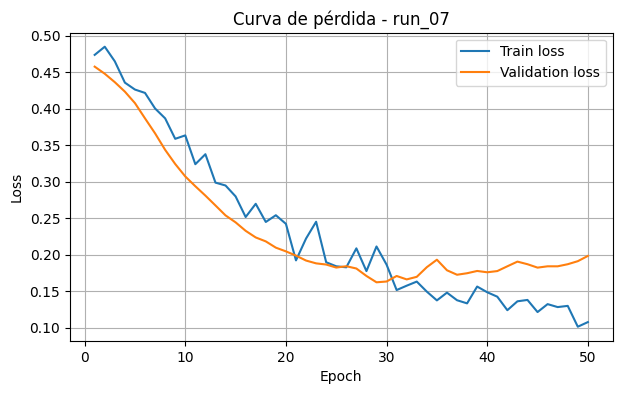

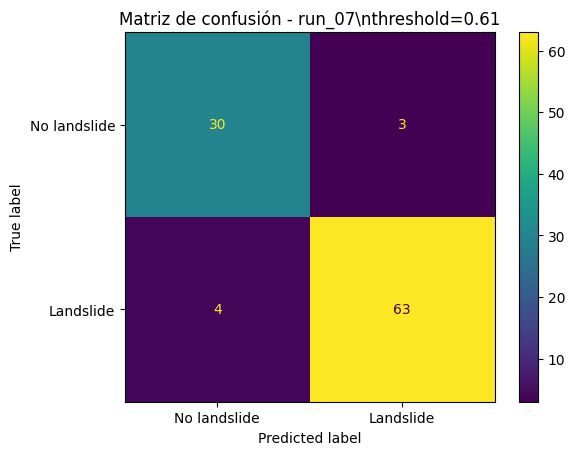

run_07 finalizado
Final epoch used: 50
Best val-loss epoch observed: 29
Best threshold: 0.61
Validation errors: 7
Ejecutando run_08 / 20
run_08 | epoch 001 | train_loss=0.6100 | val_loss=0.5501 | val_auc=0.2483
run_08 | epoch 010 | train_loss=0.3951 | val_loss=0.3230 | val_auc=0.9331
run_08 | epoch 020 | train_loss=0.2871 | val_loss=0.1810 | val_auc=0.9692
run_08 | epoch 030 | train_loss=0.2091 | val_loss=0.1231 | val_auc=0.9747
run_08 | epoch 040 | train_loss=0.1656 | val_loss=0.1066 | val_auc=0.9783
run_08 | epoch 050 | train_loss=0.1589 | val_loss=0.1037 | val_auc=0.9783


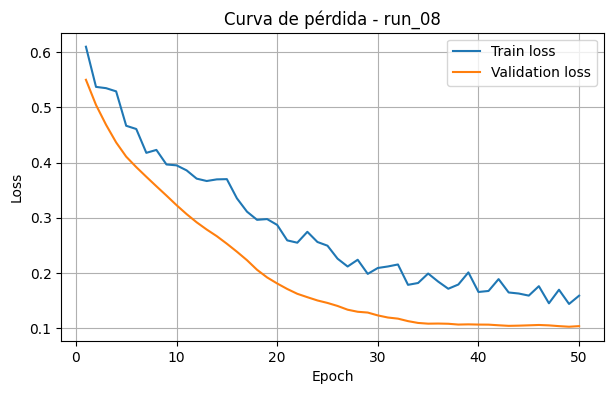

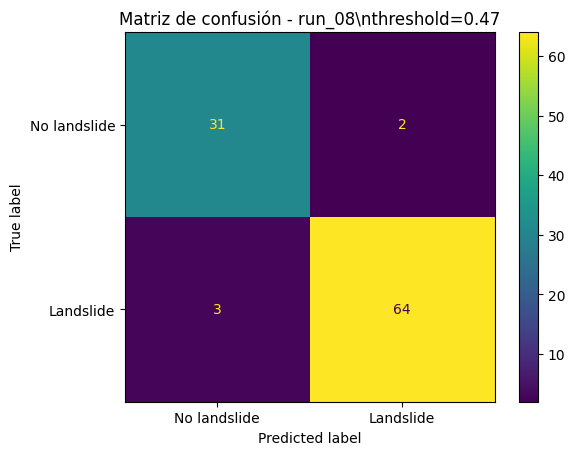

run_08 finalizado
Final epoch used: 50
Best val-loss epoch observed: 49
Best threshold: 0.47000000000000003
Validation errors: 5
Ejecutando run_09 / 20
run_09 | epoch 001 | train_loss=0.5780 | val_loss=0.4800 | val_auc=0.4794
run_09 | epoch 010 | train_loss=0.3310 | val_loss=0.2739 | val_auc=0.9290
run_09 | epoch 020 | train_loss=0.2455 | val_loss=0.2060 | val_auc=0.9466
run_09 | epoch 030 | train_loss=0.1473 | val_loss=0.1945 | val_auc=0.9525
run_09 | epoch 040 | train_loss=0.1085 | val_loss=0.2115 | val_auc=0.9543
run_09 | epoch 050 | train_loss=0.0975 | val_loss=0.2613 | val_auc=0.9516


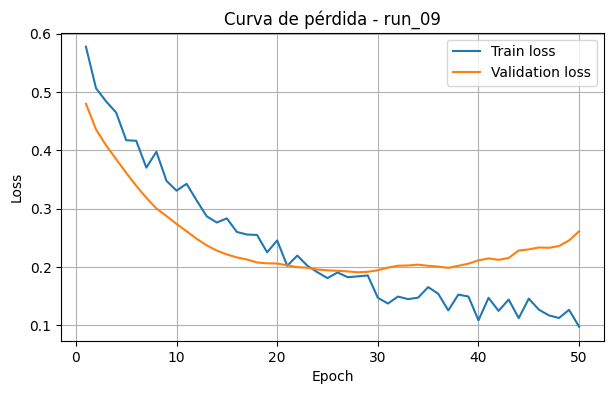

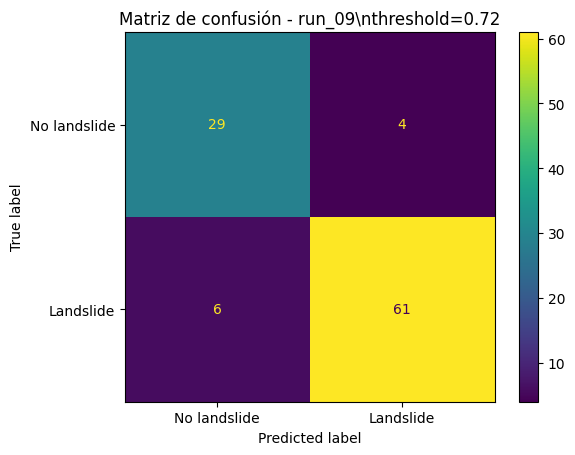

run_09 finalizado
Final epoch used: 50
Best val-loss epoch observed: 28
Best threshold: 0.72
Validation errors: 10
Ejecutando run_10 / 20
run_10 | epoch 001 | train_loss=0.5433 | val_loss=0.4943 | val_auc=0.4034
run_10 | epoch 010 | train_loss=0.3255 | val_loss=0.2671 | val_auc=0.9647
run_10 | epoch 020 | train_loss=0.2511 | val_loss=0.1603 | val_auc=0.9738
run_10 | epoch 030 | train_loss=0.1627 | val_loss=0.1266 | val_auc=0.9760
run_10 | epoch 040 | train_loss=0.1568 | val_loss=0.1234 | val_auc=0.9747
run_10 | epoch 050 | train_loss=0.1477 | val_loss=0.1347 | val_auc=0.9738


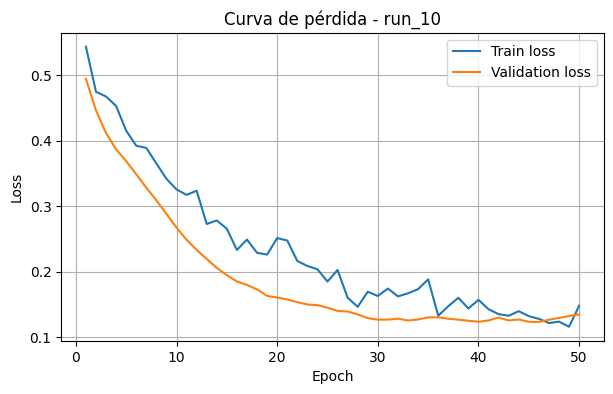

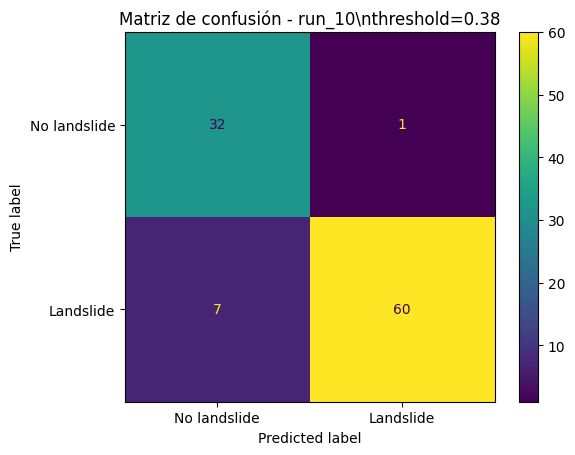

run_10 finalizado
Final epoch used: 50
Best val-loss epoch observed: 46
Best threshold: 0.38
Validation errors: 8
Ejecutando run_11 / 20
run_11 | epoch 001 | train_loss=0.5159 | val_loss=0.4563 | val_auc=0.5550
run_11 | epoch 010 | train_loss=0.3330 | val_loss=0.2800 | val_auc=0.9349
run_11 | epoch 020 | train_loss=0.2183 | val_loss=0.1765 | val_auc=0.9683
run_11 | epoch 030 | train_loss=0.1616 | val_loss=0.1377 | val_auc=0.9742
run_11 | epoch 040 | train_loss=0.1362 | val_loss=0.1263 | val_auc=0.9783
run_11 | epoch 050 | train_loss=0.1159 | val_loss=0.1261 | val_auc=0.9787


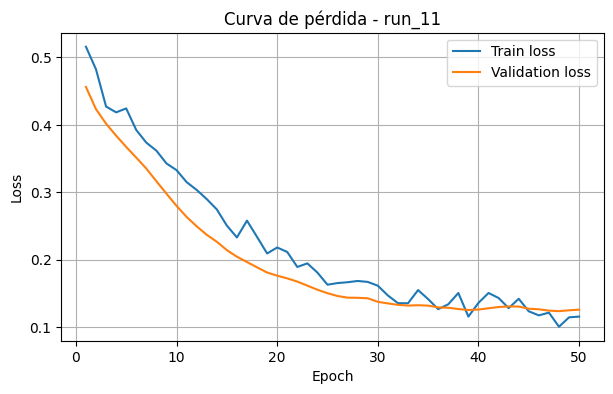

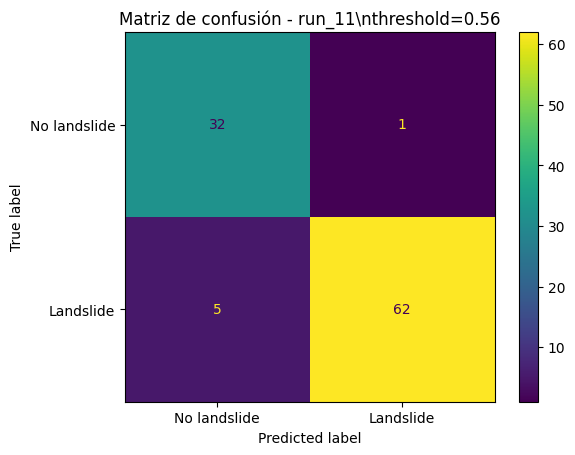

run_11 finalizado
Final epoch used: 50
Best val-loss epoch observed: 48
Best threshold: 0.56
Validation errors: 6
Ejecutando run_12 / 20
run_12 | epoch 001 | train_loss=0.4642 | val_loss=0.4270 | val_auc=0.7105
run_12 | epoch 010 | train_loss=0.3863 | val_loss=0.2920 | val_auc=0.9190
run_12 | epoch 020 | train_loss=0.2978 | val_loss=0.1825 | val_auc=0.9711
run_12 | epoch 030 | train_loss=0.2042 | val_loss=0.1503 | val_auc=0.9801
run_12 | epoch 040 | train_loss=0.1570 | val_loss=0.1671 | val_auc=0.9806
run_12 | epoch 050 | train_loss=0.1381 | val_loss=0.1499 | val_auc=0.9796


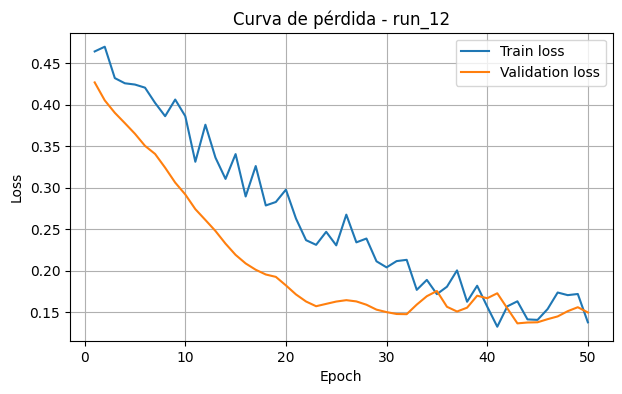

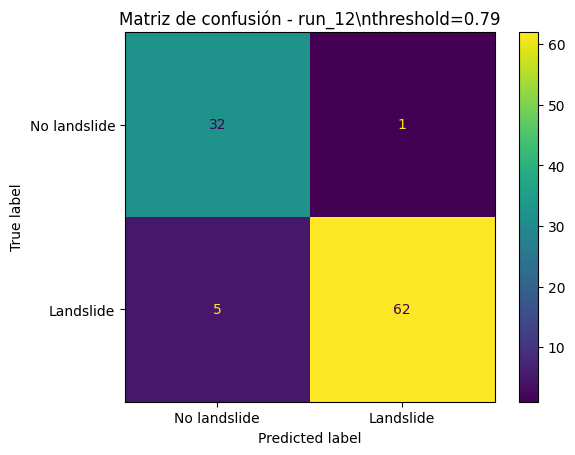

run_12 finalizado
Final epoch used: 50
Best val-loss epoch observed: 43
Best threshold: 0.79
Validation errors: 6
Ejecutando run_13 / 20
run_13 | epoch 001 | train_loss=0.5480 | val_loss=0.4497 | val_auc=0.5654
run_13 | epoch 010 | train_loss=0.3636 | val_loss=0.2975 | val_auc=0.9417
run_13 | epoch 020 | train_loss=0.2382 | val_loss=0.2279 | val_auc=0.9403
run_13 | epoch 030 | train_loss=0.1751 | val_loss=0.2137 | val_auc=0.9362
run_13 | epoch 040 | train_loss=0.1465 | val_loss=0.2492 | val_auc=0.9340
run_13 | epoch 050 | train_loss=0.1316 | val_loss=0.2829 | val_auc=0.9394


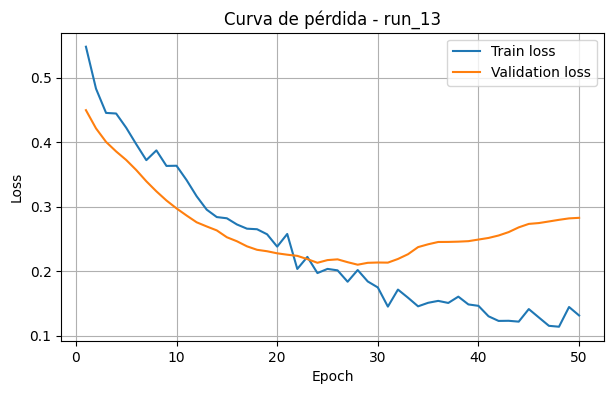

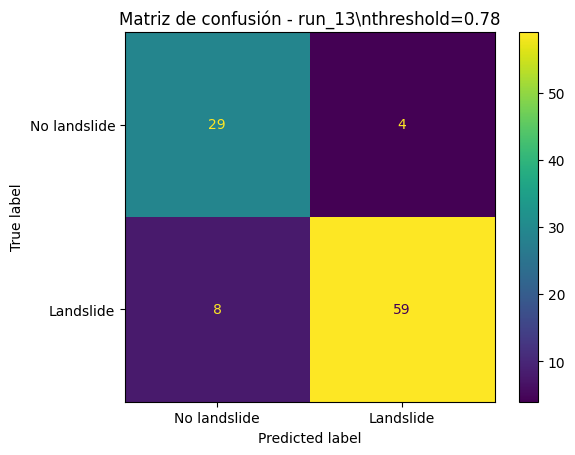

run_13 finalizado
Final epoch used: 50
Best val-loss epoch observed: 28
Best threshold: 0.78
Validation errors: 12
Ejecutando run_14 / 20
run_14 | epoch 001 | train_loss=0.4998 | val_loss=0.4763 | val_auc=0.4437
run_14 | epoch 010 | train_loss=0.3363 | val_loss=0.2476 | val_auc=0.9701
run_14 | epoch 020 | train_loss=0.2317 | val_loss=0.1607 | val_auc=0.9729
run_14 | epoch 030 | train_loss=0.1693 | val_loss=0.1641 | val_auc=0.9688
run_14 | epoch 040 | train_loss=0.1288 | val_loss=0.1930 | val_auc=0.9715
run_14 | epoch 050 | train_loss=0.1081 | val_loss=0.2550 | val_auc=0.9656


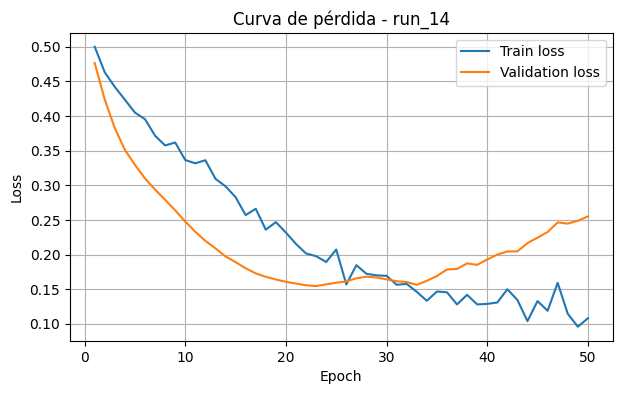

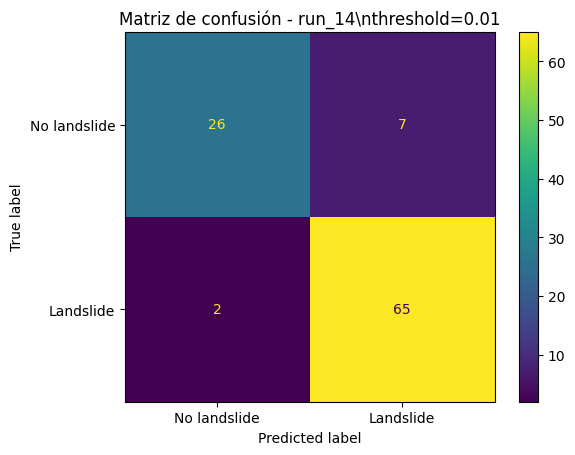

run_14 finalizado
Final epoch used: 50
Best val-loss epoch observed: 23
Best threshold: 0.01
Validation errors: 9
Ejecutando run_15 / 20
run_15 | epoch 001 | train_loss=0.5020 | val_loss=0.4715 | val_auc=0.4491
run_15 | epoch 010 | train_loss=0.3625 | val_loss=0.3425 | val_auc=0.9032
run_15 | epoch 020 | train_loss=0.2689 | val_loss=0.2237 | val_auc=0.9489
run_15 | epoch 030 | train_loss=0.2279 | val_loss=0.1791 | val_auc=0.9634
run_15 | epoch 040 | train_loss=0.1686 | val_loss=0.1685 | val_auc=0.9701
run_15 | epoch 050 | train_loss=0.1487 | val_loss=0.1687 | val_auc=0.9760


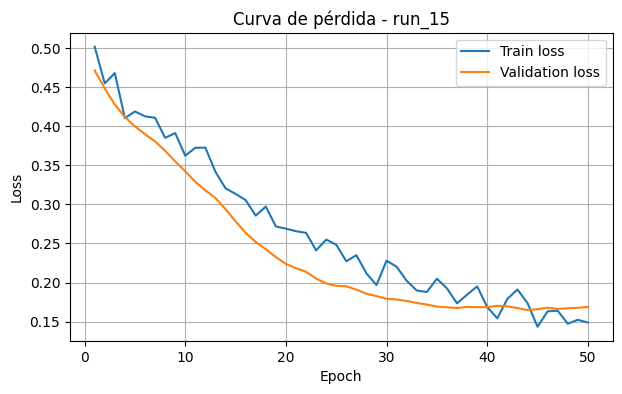

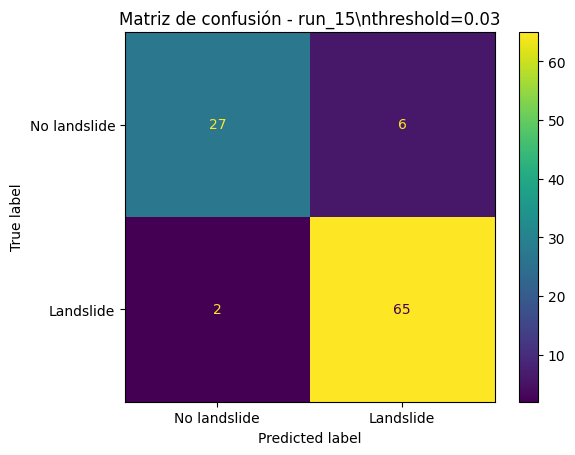

run_15 finalizado
Final epoch used: 50
Best val-loss epoch observed: 44
Best threshold: 0.03
Validation errors: 8
Ejecutando run_16 / 20
run_16 | epoch 001 | train_loss=0.4567 | val_loss=0.4145 | val_auc=0.7739
run_16 | epoch 010 | train_loss=0.3717 | val_loss=0.2792 | val_auc=0.9349
run_16 | epoch 020 | train_loss=0.2644 | val_loss=0.1498 | val_auc=0.9765
run_16 | epoch 030 | train_loss=0.2248 | val_loss=0.1223 | val_auc=0.9801
run_16 | epoch 040 | train_loss=0.1873 | val_loss=0.1141 | val_auc=0.9819
run_16 | epoch 050 | train_loss=0.1502 | val_loss=0.1228 | val_auc=0.9824


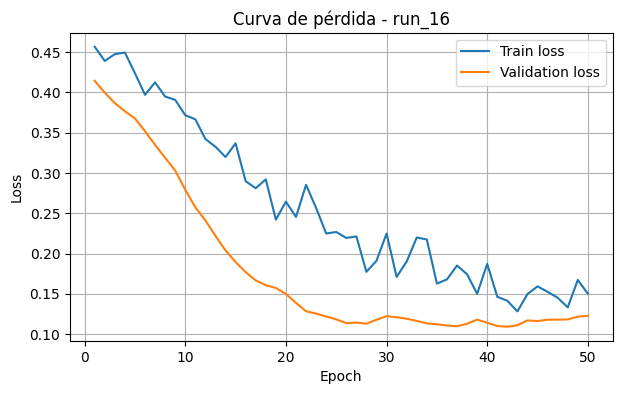

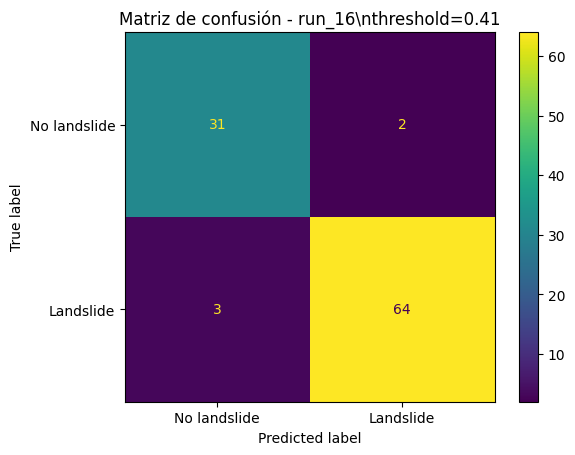

run_16 finalizado
Final epoch used: 50
Best val-loss epoch observed: 42
Best threshold: 0.41000000000000003
Validation errors: 5
Ejecutando run_17 / 20
run_17 | epoch 001 | train_loss=0.5134 | val_loss=0.4457 | val_auc=0.5721
run_17 | epoch 010 | train_loss=0.3236 | val_loss=0.2300 | val_auc=0.9778
run_17 | epoch 020 | train_loss=0.2265 | val_loss=0.1292 | val_auc=0.9815
run_17 | epoch 030 | train_loss=0.1796 | val_loss=0.0937 | val_auc=0.9882
run_17 | epoch 040 | train_loss=0.1388 | val_loss=0.0893 | val_auc=0.9869
run_17 | epoch 050 | train_loss=0.1127 | val_loss=0.0926 | val_auc=0.9860


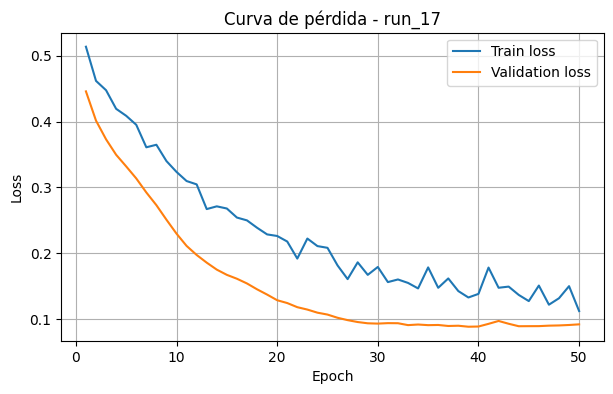

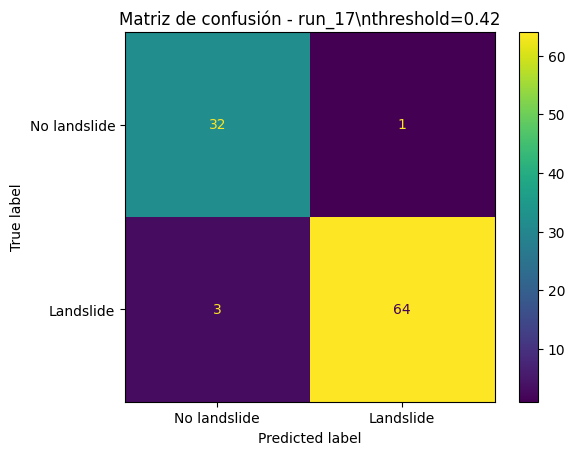

run_17 finalizado
Final epoch used: 50
Best val-loss epoch observed: 39
Best threshold: 0.42000000000000004
Validation errors: 4
Ejecutando run_18 / 20
run_18 | epoch 001 | train_loss=0.4433 | val_loss=0.4007 | val_auc=0.7635
run_18 | epoch 010 | train_loss=0.3578 | val_loss=0.2333 | val_auc=0.9706
run_18 | epoch 020 | train_loss=0.2365 | val_loss=0.1341 | val_auc=0.9828
run_18 | epoch 030 | train_loss=0.1774 | val_loss=0.1045 | val_auc=0.9842
run_18 | epoch 040 | train_loss=0.1282 | val_loss=0.1274 | val_auc=0.9887
run_18 | epoch 050 | train_loss=0.1319 | val_loss=0.1318 | val_auc=0.9905


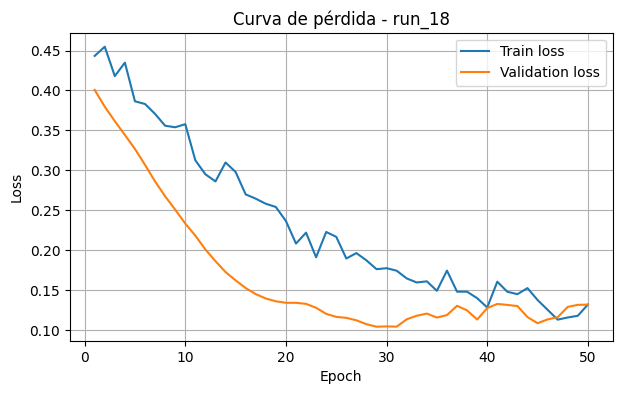

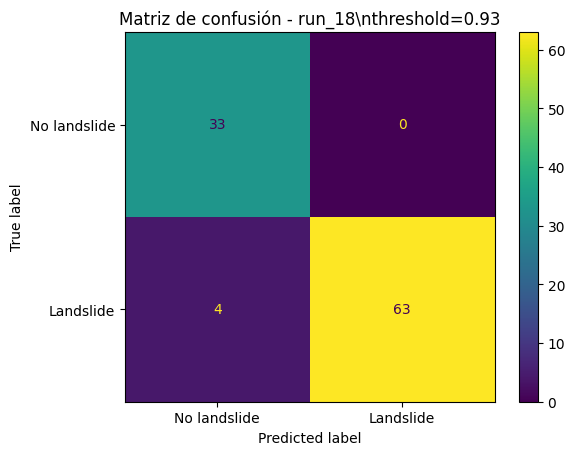

run_18 finalizado
Final epoch used: 50
Best val-loss epoch observed: 29
Best threshold: 0.93
Validation errors: 4
Ejecutando run_19 / 20
run_19 | epoch 001 | train_loss=0.4744 | val_loss=0.3815 | val_auc=0.8363
run_19 | epoch 010 | train_loss=0.3448 | val_loss=0.2291 | val_auc=0.9688
run_19 | epoch 020 | train_loss=0.2285 | val_loss=0.1316 | val_auc=0.9828
run_19 | epoch 030 | train_loss=0.1902 | val_loss=0.0998 | val_auc=0.9860
run_19 | epoch 040 | train_loss=0.1286 | val_loss=0.0907 | val_auc=0.9864
run_19 | epoch 050 | train_loss=0.1482 | val_loss=0.0882 | val_auc=0.9860


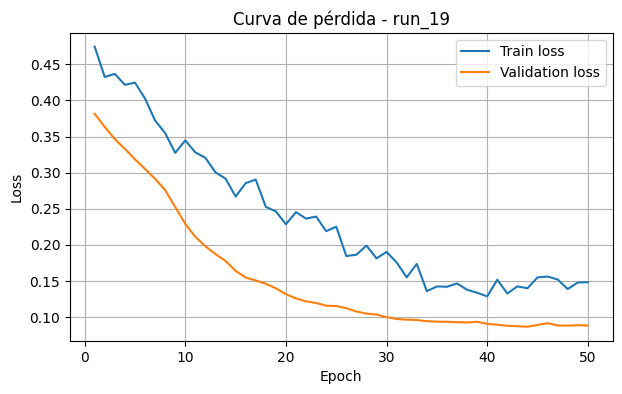

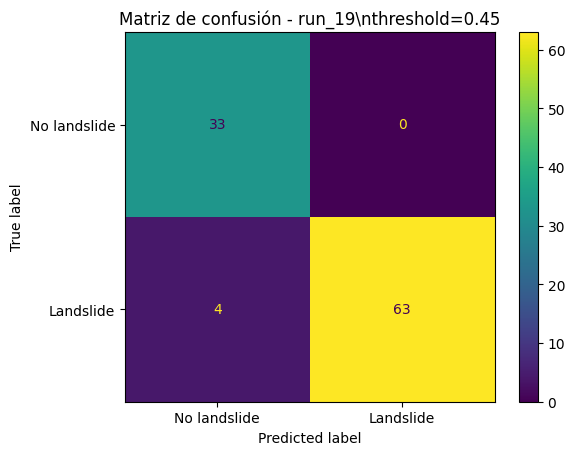

run_19 finalizado
Final epoch used: 50
Best val-loss epoch observed: 44
Best threshold: 0.45
Validation errors: 4
Ejecutando run_20 / 20
run_20 | epoch 001 | train_loss=0.4682 | val_loss=0.3772 | val_auc=0.8607
run_20 | epoch 010 | train_loss=0.3320 | val_loss=0.2396 | val_auc=0.9602
run_20 | epoch 020 | train_loss=0.2509 | val_loss=0.1485 | val_auc=0.9729
run_20 | epoch 030 | train_loss=0.1748 | val_loss=0.1384 | val_auc=0.9783
run_20 | epoch 040 | train_loss=0.1580 | val_loss=0.1379 | val_auc=0.9819
run_20 | epoch 050 | train_loss=0.1216 | val_loss=0.1185 | val_auc=0.9837


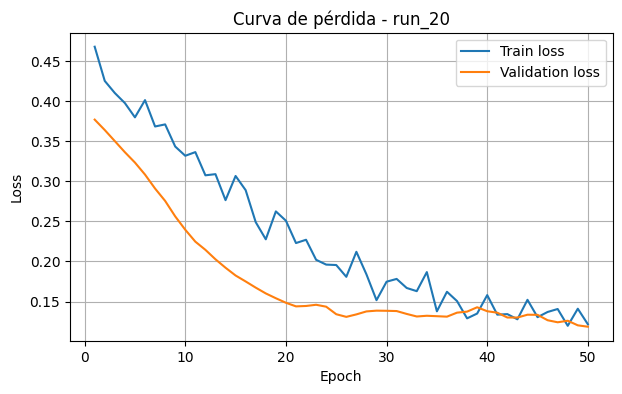

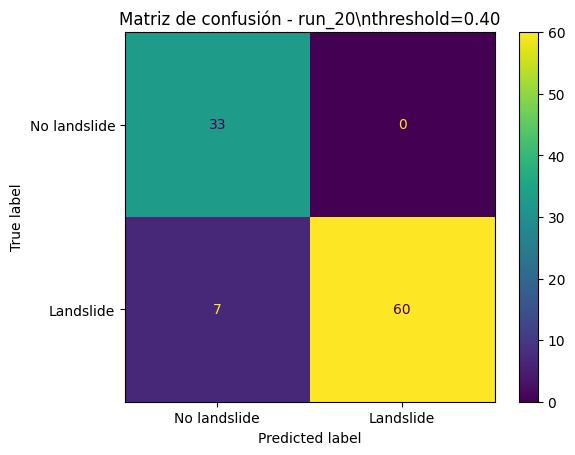

run_20 finalizado
Final epoch used: 50
Best val-loss epoch observed: 50
Best threshold: 0.4
Validation errors: 7
Experimento completo: 20 corridas finalizadas.


In [ ]:

experiment_results = []

for run_id in range(1, N_RUNS + 1):
    result = run_one_random_split(run_id)
    experiment_results.append(result)

print("Experimento completo: 20 corridas finalizadas.")

In [ ]:

all_metrics_df = pd.concat(
    [result["metrics_df"] for result in experiment_results],
    ignore_index=True
)

all_history_df = pd.concat(
    [result["history_df"] for result in experiment_results],
    ignore_index=True
)

all_threshold_summary_df = pd.concat(
    [result["threshold_summary_df"] for result in experiment_results],
    ignore_index=True
)

all_class_distribution_df = pd.concat(
    [result["class_distribution_df"] for result in experiment_results],
    ignore_index=True
)

all_metrics_df.to_excel(
    os.path.join(OUTPUT_ROOT, "all_metrics_20_random_splits.xlsx"),
    index=False
)

all_history_df.to_csv(
    os.path.join(OUTPUT_ROOT, "all_training_history_20_random_splits.csv"),
    index=False
)

all_threshold_summary_df.to_excel(
    os.path.join(OUTPUT_ROOT, "all_threshold_summary_20_random_splits.xlsx"),
    index=False
)

all_class_distribution_df.to_excel(
    os.path.join(OUTPUT_ROOT, "all_class_distribution_20_random_splits.xlsx"),
    index=False
)

validation_metrics_df = (
    all_metrics_df
    .query("split == 'Validation'")
    .copy()
    .sort_values("run")
    .reset_index(drop=True)
)

validation_metrics_df.to_excel(
    os.path.join(OUTPUT_ROOT, "validation_metrics_20_random_splits.xlsx"),
    index=False
)

metric_cols = [
    "loss",
    "AUC",
    "AUPRC",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "MCC",
    "Balanced_Accuracy",
    "Brier",
    "best_threshold",
    "best_epoch_by_val_loss",
    "final_epoch_used",
    "best_val_loss_observed",
    "validation_errors",
    "train_time_seconds"
]

summary_metrics_df = (
    validation_metrics_df[metric_cols]
    .agg(["mean", "std", "min", "max"])
    .T
    .reset_index()
    .rename(columns={"index": "metric"})
)

summary_metrics_df.to_excel(
    os.path.join(OUTPUT_ROOT, "summary_mean_std_validation_metrics.xlsx"),
    index=False
)

display(validation_metrics_df)
display(summary_metrics_df)

,run,run_name,n_heads,split,loss,best_threshold,best_epoch_by_val_loss,best_val_loss_observed,final_epoch_used,train_time_seconds,...,validation_errors,AUC,AUPRC,Accuracy,Precision,Recall,F1,MCC,Balanced_Accuracy,Brier
0,1,run_01,2,Validation,0.092934,0.12,46,0.084555,50,8.194317,...,4.0,0.989145,0.995207,0.96,1.000000,0.940299,0.969231,0.915775,0.970149,0.045920
1,2,run_02,2,Validation,0.074377,0.53,39,0.073013,50,5.634348,...,2.0,0.997286,0.998656,0.98,0.985075,0.985075,0.985075,0.954772,0.977386,0.019734
2,3,run_03,2,Validation,0.210270,0.92,37,0.153176,50,4.701517,...,7.0,0.966531,0.979294,0.93,0.968750,0.925373,0.946565,0.847134,0.932384,0.076664
3,4,run_04,2,Validation,0.181945,0.51,40,0.153325,50,5.399068,...,7.0,0.977838,0.989824,0.93,0.941176,0.955224,0.948148,0.840692,0.917006,0.064520
4,5,run_05,2,Validation,0.107240,0.05,45,0.104203,50,5.154347,...,4.0,0.982361,0.992421,0.96,0.956522,0.985075,0.970588,0.909090,0.947083,0.057346
5,6,run_06,2,Validation,0.187493,0.92,48,0.159796,50,4.612642,...,8.0,0.976481,0.989141,0.92,0.983607,0.895522,0.937500,0.834110,0.932610,0.084847
6,7,run_07,2,Validation,0.198254,0.61,29,0.162117,50,5.504395,...,7.0,0.970602,0.987744,0.93,0.954545,0.940299,0.947368,0.843121,0.924695,0.073456
7,8,run_08,2,Validation,0.103734,0.47,49,0.102665,50,4.638889,...,5.0,0.978290,0.991579,0.95,0.969697,0.955224,0.962406,0.888015,0.947309,0.045260
8,9,run_09,2,Validation,0.261274,0.72,28,0.190974,50,5.176728,...,10.0,0.951606,0.977999,0.90,0.938462,0.910448,0.924242,0.778055,0.894618,0.089266
9,10,run_10,2,Validation,0.134744,0.38,46,0.123018,50,4.899611,...,8.0,0.973768,0.988491,0.92,0.983607,0.895522,0.937500,0.834110,0.932610,0.068644


,metric,mean,std,min,max
0,loss,0.154442,0.061705,0.074377,0.282898
1,AUC,0.976594,0.013308,0.939394,0.997286
2,AUPRC,0.988472,0.008998,0.956918,0.998656
3,Accuracy,0.936500,0.024339,0.880000,0.980000
4,Precision,0.967939,0.028640,0.902778,1.000000
5,Recall,0.937313,0.030473,0.880597,0.985075
6,F1,0.951837,0.018520,0.907692,0.985075
7,MCC,0.861479,0.053716,0.739580,0.954772
8,Balanced_Accuracy,0.936081,0.030000,0.879014,0.977386
9,Brier,0.064263,0.021668,0.019734,0.107380


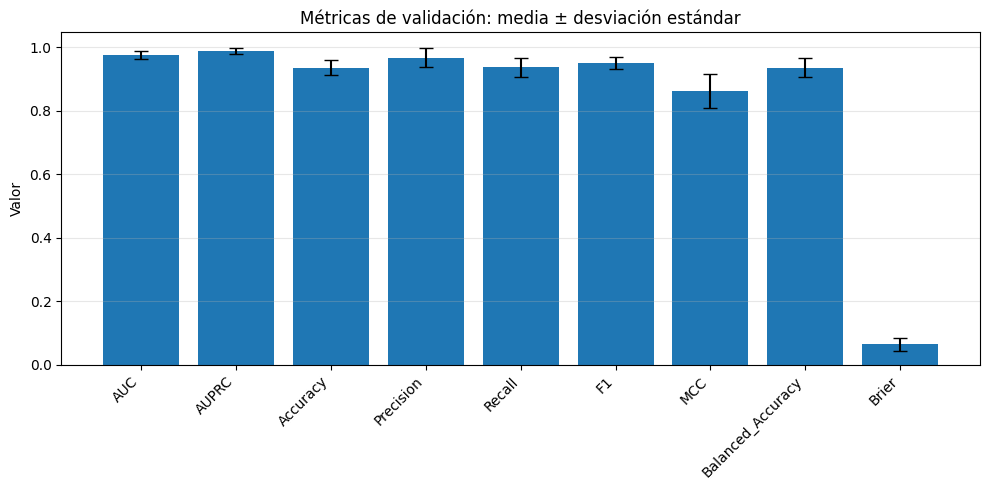

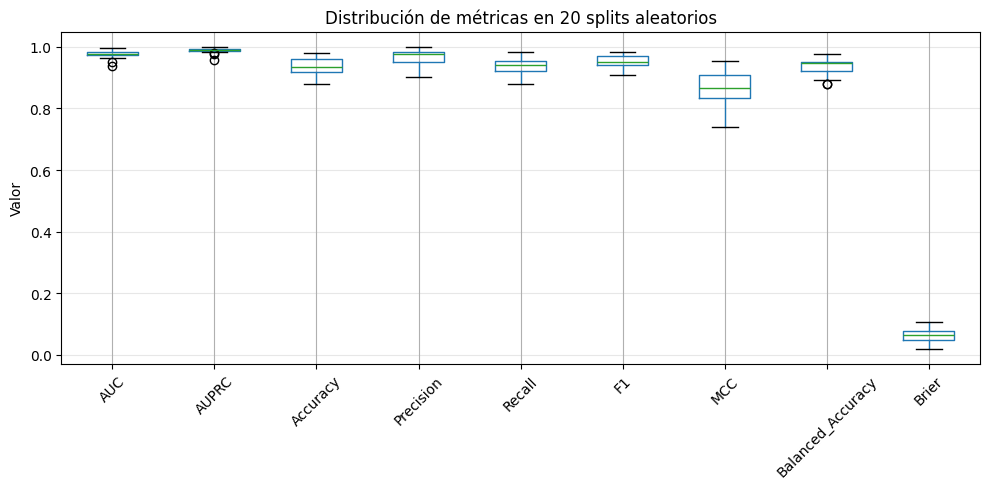

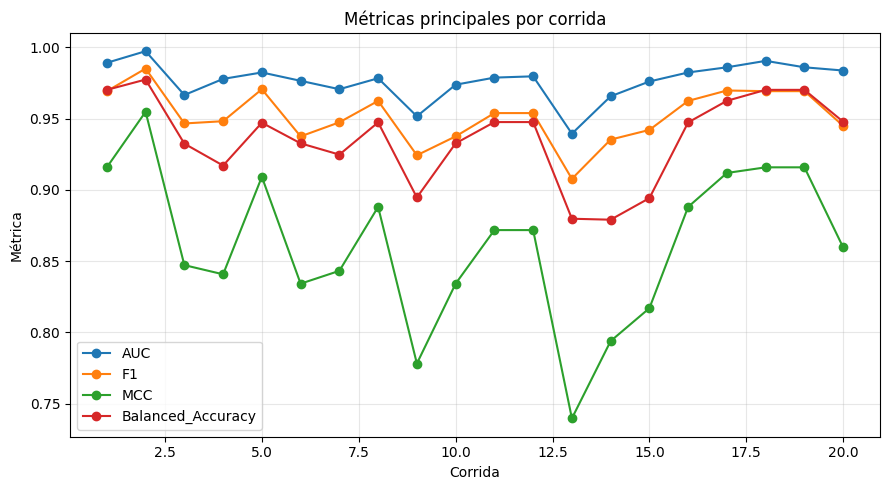

In [ ]:

selected_metrics = [
    "AUC",
    "AUPRC",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "MCC",
    "Balanced_Accuracy",
    "Brier"
]

means = validation_metrics_df[selected_metrics].mean()
stds = validation_metrics_df[selected_metrics].std()

plt.figure(figsize=(10, 5))
x = np.arange(len(selected_metrics))

plt.bar(x, means.values, yerr=stds.values, capsize=5)
plt.xticks(x, selected_metrics, rotation=45, ha="right")
plt.ylabel("Valor")
plt.title("Métricas de validación: media ± desviación estándar")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

save_current_figure(
    os.path.join(OUTPUT_ROOT, "validation_metrics_mean_std.png"),
    dpi=300
)
plt.show()


plt.figure(figsize=(10, 5))
validation_metrics_df[selected_metrics].boxplot(rot=45)
plt.ylabel("Valor")
plt.title("Distribución de métricas en 20 splits aleatorios")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

save_current_figure(
    os.path.join(OUTPUT_ROOT, "validation_metrics_boxplot.png"),
    dpi=300
)
plt.show()


line_metrics = ["AUC", "F1", "MCC", "Balanced_Accuracy"]
plt.figure(figsize=(9, 5))

for metric in line_metrics:
    plt.plot(
        validation_metrics_df["run"],
        validation_metrics_df[metric],
        marker="o",
        label=metric
    )

plt.xlabel("Corrida")
plt.ylabel("Métrica")
plt.title("Métricas principales por corrida")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

save_current_figure(
    os.path.join(OUTPUT_ROOT, "main_metrics_by_run.png"),
    dpi=300
)
plt.show()

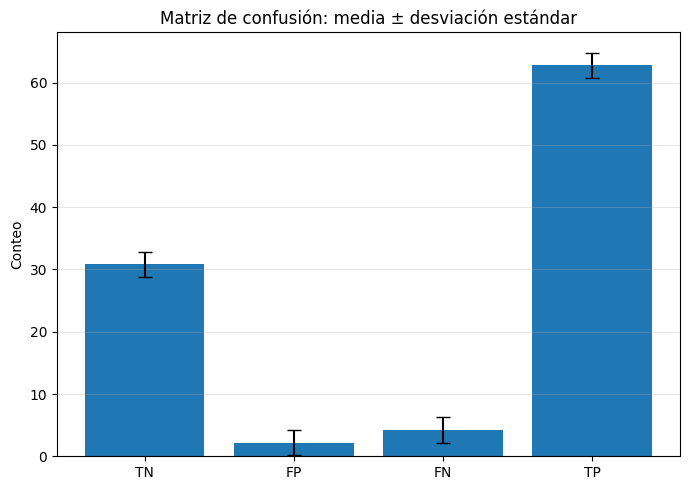

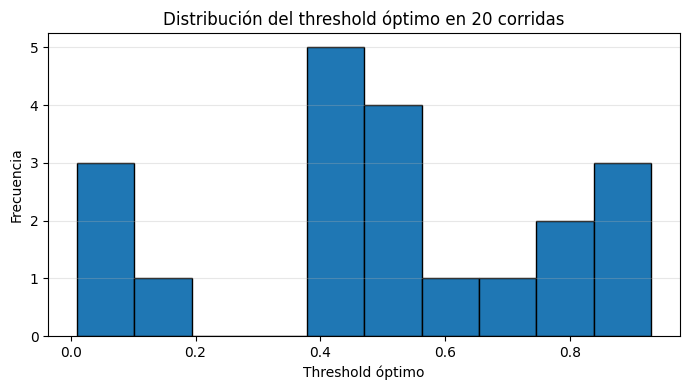

In [ ]:

confusion_cols = ["TN", "FP", "FN", "TP"]

conf_means = validation_metrics_df[confusion_cols].mean()
conf_stds = validation_metrics_df[confusion_cols].std()

plt.figure(figsize=(7, 5))
x = np.arange(len(confusion_cols))

plt.bar(x, conf_means.values, yerr=conf_stds.values, capsize=5)
plt.xticks(x, confusion_cols)
plt.ylabel("Conteo")
plt.title("Matriz de confusión: media ± desviación estándar")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

save_current_figure(
    os.path.join(OUTPUT_ROOT, "confusion_counts_mean_std.png"),
    dpi=300
)
plt.show()


plt.figure(figsize=(7, 4))
plt.hist(validation_metrics_df["best_threshold"], bins=10, edgecolor="black")
plt.xlabel("Threshold óptimo")
plt.ylabel("Frecuencia")
plt.title("Distribución del threshold óptimo en 20 corridas")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

save_current_figure(
    os.path.join(OUTPUT_ROOT, "threshold_distribution.png"),
    dpi=300
)
plt.show()

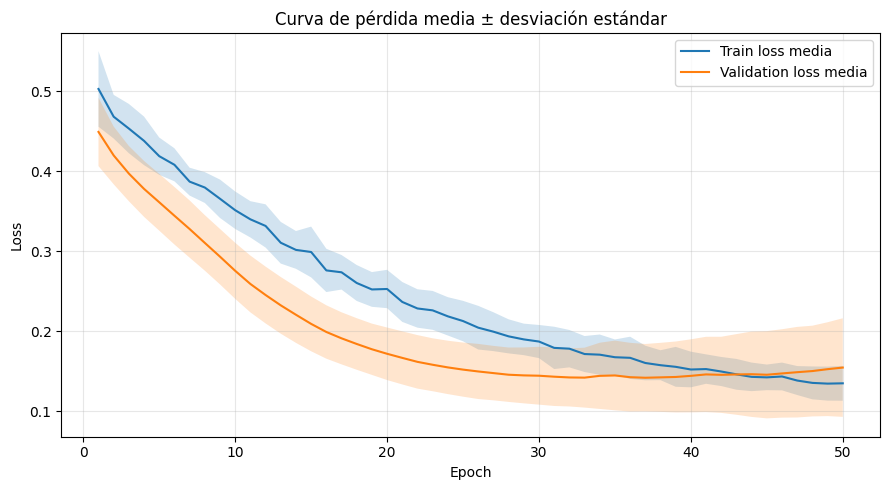

In [ ]:

history_pivot_train = all_history_df.pivot_table(
    index="epoch",
    columns="run",
    values="train_loss"
)

history_pivot_val = all_history_df.pivot_table(
    index="epoch",
    columns="run",
    values="val_loss"
)

train_mean = history_pivot_train.mean(axis=1)
train_std = history_pivot_train.std(axis=1)

val_mean = history_pivot_val.mean(axis=1)
val_std = history_pivot_val.std(axis=1)

epochs = train_mean.index.values

plt.figure(figsize=(9, 5))

plt.plot(epochs, train_mean.values, label="Train loss media")
plt.fill_between(
    epochs,
    train_mean.values - train_std.values,
    train_mean.values + train_std.values,
    alpha=0.2
)

plt.plot(epochs, val_mean.values, label="Validation loss media")
plt.fill_between(
    epochs,
    val_mean.values - val_std.values,
    val_mean.values + val_std.values,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Curva de pérdida media ± desviación estándar")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

save_current_figure(
    os.path.join(OUTPUT_ROOT, "loss_curve_mean_std_20_runs.png"),
    dpi=300
)
plt.show()

In [ ]:

def interpret_stability(summary_df):
    rows = []

    for metric in ["AUC", "F1", "MCC", "Balanced_Accuracy", "Brier"]:
        sub = summary_df[summary_df["metric"] == metric]

        if len(sub) == 0:
            continue

        mean_val = float(sub["mean"].iloc[0])
        std_val = float(sub["std"].iloc[0])

        rows.append({
            "metric": metric,
            "mean": mean_val,
            "std": std_val,
            "coef_variation": std_val / abs(mean_val) if mean_val != 0 else np.nan
        })

    interpretation_df = pd.DataFrame(rows)

    interpretation_df.to_excel(
        os.path.join(OUTPUT_ROOT, "stability_interpretation_metrics.xlsx"),
        index=False
    )

    return interpretation_df

stability_df = interpret_stability(summary_metrics_df)

display(stability_df)

print("Lectura sugerida:")
print("- Desviaciones estándar bajas indican que el modelo no depende fuertemente de un único split.")
print("- Si la desviación estándar de AUC, F1, MCC y Balanced Accuracy es pequeña, el resultado es más estable.")
print("- Si alguna métrica varía mucho, conviene reportar promedio ± desviación estándar en lugar de un único valor.")

,metric,mean,std,coef_variation
0,AUC,0.976594,0.013308,0.013627
1,F1,0.951837,0.018520,0.019457
2,MCC,0.861479,0.053716,0.062354
3,Balanced_Accuracy,0.936081,0.030000,0.032048
4,Brier,0.064263,0.021668,0.337174


Lectura sugerida:
- Desviaciones estándar bajas indican que el modelo no depende fuertemente de un único split.
- Si la desviación estándar de AUC, F1, MCC y Balanced Accuracy es pequeña, el resultado es más estable.
- Si alguna métrica varía mucho, conviene reportar promedio ± desviación estándar en lugar de un único valor.


In [ ]:

ZIP_NAME = "GeoFormer_20_random_splits_2_heads_fixed_epochs.zip"

if os.path.exists(ZIP_NAME):
    os.remove(ZIP_NAME)

shutil.make_archive(
    base_name=ZIP_NAME.replace(".zip", ""),
    format="zip",
    root_dir=OUTPUT_ROOT
)

print("ZIP creado:", ZIP_NAME)
print("Carpeta de resultados:", OUTPUT_ROOT)

# Descomenta esta línea en Colab si quieres descargar automáticamente:
# files.download(ZIP_NAME)

ZIP creado: GeoFormer_20_random_splits_2_heads_fixed_epochs.zip
Carpeta de resultados: GeoFormer_outputs_20_random_splits_2_heads_fixed_epochs


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>